In [1]:
import pandas as pd
import numpy as np
from urllib.parse import urlparse
import tldextract
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate
import re
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
VISUALIZATION_DIR = "../../visualizations"
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

def load_phishing_data(file_path1, file_path2):
    combined_phishing_df = pd.DataFrame(columns=['url', 'label'])
    loaded_at_least_one = False
    
    if os.path.exists(file_path1):
        try:
            df1 = pd.read_csv(file_path1, encoding='utf-8', on_bad_lines='skip')
            print(f"Loaded {len(df1)} URLs from {file_path1}")
            df1 = df1.dropna(subset=['url'])
            df1['url'] = df1['url'].astype(str)
            df1['label'] = 1
            combined_phishing_df = pd.concat([combined_phishing_df, df1], ignore_index=True)
            loaded_at_least_one = True
        except Exception as e:
            print(f"Error loading {file_path1}: {e}")

    if os.path.exists(file_path2):
        try:
            df2 = pd.read_csv(file_path2, encoding='utf-8', on_bad_lines='skip')
            print(f"Loaded {len(df2)} URLs from {file_path2}")
            df2 = df2[df2['label'] == 1]
            df2 = df2.dropna(subset=['url'])
            df2['url'] = df2['url'].astype(str)
            combined_phishing_df = pd.concat([combined_phishing_df, df2], ignore_index=True)
            loaded_at_least_one = True
        except Exception as e:
            print(f"Error loading {file_path2}: {e}")

    if not loaded_at_least_one:
        print("Error: Failed to load any phishing datasets.")
        return None

    combined_phishing_df = combined_phishing_df.drop_duplicates(subset=['url'])
    print(f"Total phishing URLs after deduplication: {len(combined_phishing_df)}")
    return combined_phishing_df[['url', 'label']]

def load_alexa_data(file_path):
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return None
    try:
        df = pd.read_csv(file_path, names=['rank', 'url'])
        print(f"Loaded {len(df)} URLs from {file_path}")
        df['label'] = 0
        df = df.dropna(subset=['url'])
        df['url'] = df['url'].astype(str)
        return df[['url', 'label']]
    except Exception as e:
        print(f"Error loading Alexa data: {e}")
        return None

def load_legitimate_data(file_path):
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return None
    try:
        df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')
        print(f"Loaded {len(df)} URLs from {file_path}")
        df['label'] = 0
        df = df.dropna(subset=['url'])
        df['url'] = df['url'].astype(str)
        return df[['url', 'label']]
    except Exception as e:
        print(f"Error loading legitimate data: {e}")
        return None

def extract_url_features(url):
    if pd.isna(url):
        return pd.Series([0] * 13)
    parsed = urlparse(url)
    extracted = tldextract.extract(url)
    url_length = len(url)
    domain_length = len(extracted.domain)
    tld_length = len(extracted.suffix)
    subdomain_count = len(extracted.subdomain.split('.')) if extracted.subdomain else 0
    digit_count = sum(c.isdigit() for c in url)
    special_char_count = sum(1 for c in url if not c.isalnum())
    has_https = 1 if parsed.scheme == 'https' else 0
    has_query = 1 if parsed.query else 0
    has_path = 1 if parsed.path else 0
    has_fragment = 1 if parsed.fragment else 0
    has_ip = 1 if re.match(r'\d+\.\d+\.\d+\.\d+', extracted.domain) else 0
    hyphen_count = url.count('-')
    dot_count = url.count('.')
    return pd.Series([url_length, domain_length, tld_length, subdomain_count,
                      digit_count, special_char_count, has_https, has_query,
                      has_path, has_fragment, has_ip, hyphen_count, dot_count])

def create_feature_extraction_model(vocab_size, max_length):
    url_input = Input(shape=(max_length,))
    embedding = Embedding(vocab_size, 128)(url_input)
    lstm1 = LSTM(64, return_sequences=True)(embedding)
    lstm2 = LSTM(32)(lstm1)
    manual_input = Input(shape=(13,))
    dense_manual = Dense(32, activation='relu')(manual_input)
    concatenated = Concatenate()([lstm2, dense_manual])
    dense1 = Dense(64, activation='relu')(concatenated)
    output = Dense(32, activation='relu')(dense1)
    return Model(inputs=[url_input, manual_input], outputs=output)

def plot_feature_distribution(df, feature, filename):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=feature, hue="label", bins=50)
    plt.title(f"Distribution of {feature}")
    plt.savefig(os.path.join(VISUALIZATION_DIR, f"{filename}.png"))
    plt.close()

def process_datasets(phishing_file1, phishing_file2, alexa_file, legit_file, output_file, feature_extractor_path='feature_extractor.h5', tokenizer_path='tokenizer.pkl'):
    print("Loading datasets...")
    phishing_df = load_phishing_data(phishing_file1, phishing_file2)
    alexa_df = load_alexa_data(alexa_file)
    legit_df = load_legitimate_data(legit_file)
    
    if phishing_df is None or alexa_df is None or legit_df is None:
        raise ValueError("One or more datasets failed to load.")

    combined_df = pd.concat([phishing_df, alexa_df, legit_df], ignore_index=True)
    print(f"Total URLs: {len(combined_df)}")
    
    combined_df = combined_df.dropna(subset=['url'])
    combined_df['url'] = combined_df['url'].astype(str)
    combined_df = combined_df.drop_duplicates(subset=['url'])
    print(f"After removing duplicates and NaN URLs: {len(combined_df)}")
    
    print("Extracting manual features...")
    feature_columns = ['url_length', 'domain_length', 'tld_length', 'subdomain_count',
                       'digit_count', 'special_char_count', 'has_https', 'has_query',
                       'has_path', 'has_fragment', 'has_ip', 'hyphen_count', 'dot_count']
    manual_features = combined_df['url'].apply(extract_url_features)
    manual_features.columns = feature_columns
    
    print("Preparing URL sequences...")
    tokenizer = Tokenizer(char_level=True)
    tokenizer.fit_on_texts(combined_df['url'])
    sequences = tokenizer.texts_to_sequences(combined_df['url'])
    max_length = max(len(seq) for seq in sequences)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')
    
    print("Extracting deep learning features...")
    vocab_size = len(tokenizer.word_index) + 1
    model = create_feature_extraction_model(vocab_size, max_length)
    manual_features_array = manual_features.to_numpy()
    deep_features = model.predict([padded_sequences, manual_features_array])
    
    feature_df = pd.DataFrame(deep_features, columns=[f'deep_feature_{i}' for i in range(32)])
    final_df = pd.concat([combined_df.reset_index(drop=True), manual_features.reset_index(drop=True), feature_df], axis=1)
    
    print("Saving extracted features...")
    final_df.to_csv(output_file, index=False)
    model.save(feature_extractor_path)
    with open(tokenizer_path, 'wb') as f:
        pickle.dump({'tokenizer': tokenizer, 'max_length': max_length}, f)
    
    # Visualizations
    plot_feature_distribution(final_df, "url_length", "url_length_dist")
    plot_feature_distribution(final_df, "domain_length", "domain_length_dist")
    
    print(f"Features saved to {output_file}")
    print(f"Feature extractor saved to {feature_extractor_path}")
    print(f"Tokenizer and max_length saved to {tokenizer_path}")
    print("\nFeature Summary:")
    print(f"Total features extracted: {len(final_df.columns) - 2}")
    print(f"Manual features: {len(feature_columns)}")
    print(f"Deep learning features: 32")
    
    return final_df

if __name__ == "__main__":
    PHISHING_FILE_1 = "../../data/online_valid.csv"
    PHISHING_FILE_2 = "../../data/phishing_urls.csv"
    ALEXA_FILE = "../../data/top-1m.csv"
    LEGIT_FILE = "../../data/legitimate_urls.csv"
    OUTPUT_FILE = "../../data/extracted_features.csv"
    
    features_df = process_datasets(PHISHING_FILE_1, PHISHING_FILE_2, ALEXA_FILE, LEGIT_FILE, OUTPUT_FILE)

Loading datasets...
Loaded 150530 URLs from ../../data/online_valid.csv
Loaded 134850 URLs from ../../data/phishing_urls.csv
Total phishing URLs after deduplication: 285380
Loaded 1000000 URLs from ../../data/top-1m.csv
Loaded 2953 URLs from ../../data/legitimate_urls.csv
Total URLs: 1288333
After removing duplicates and NaN URLs: 1288260
Extracting manual features...
Preparing URL sequences...
Extracting deep learning features...
40259/40259 ━━━━━━━━━━━━━━━━━━━━ 7624s 189ms/step
Saving extracted features...


Features saved to ../../data/extracted_features.csv
Feature extractor saved to feature_extractor.h5
Tokenizer and max_length saved to tokenizer.pkl

Feature Summary:
Total features extracted: 45
Manual features: 13
Deep learning features: 32


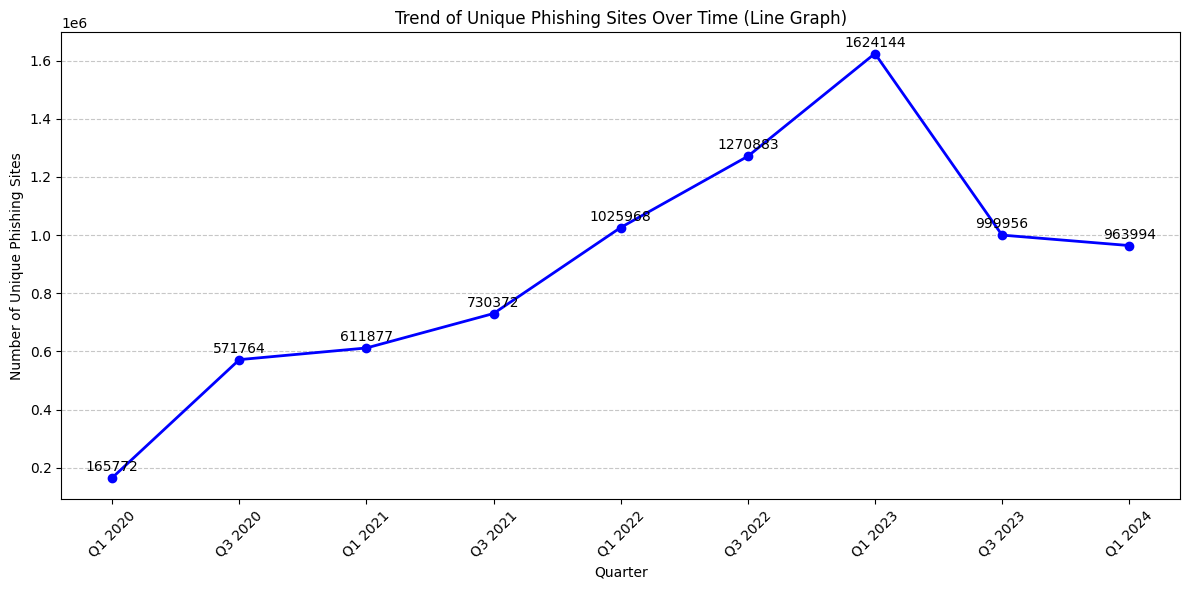

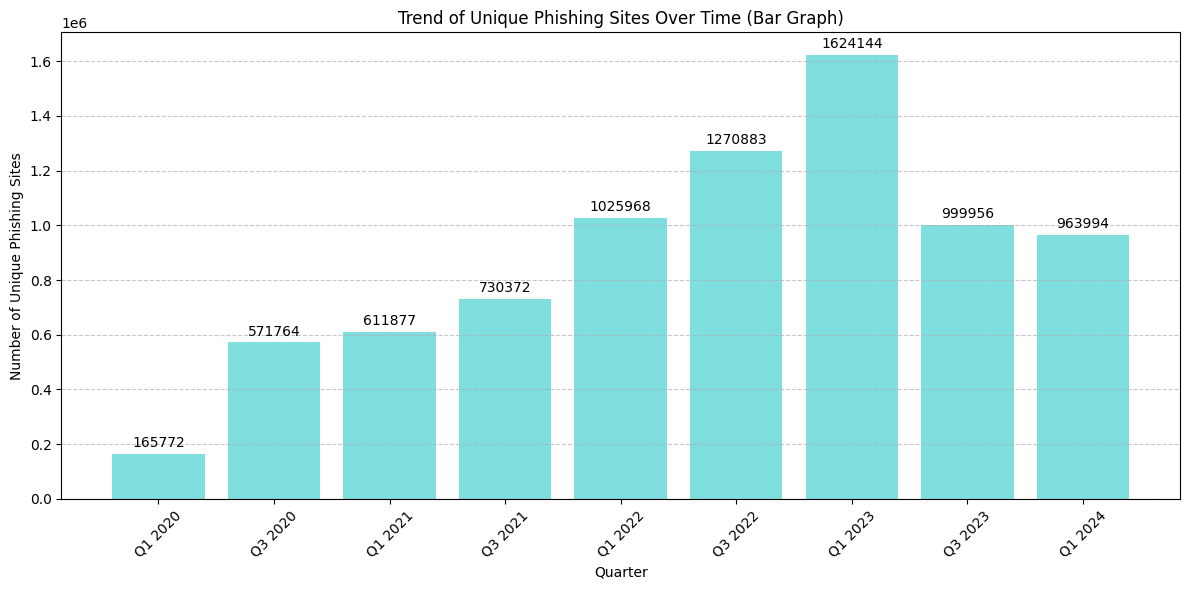

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Data extracted from the image
quarters = [
    "Q1 2020", "Q3 2020", "Q1 2021", "Q3 2021", "Q1 2022", "Q3 2022", "Q1 2023", "Q3 2023", "Q1 2024"
]

unique_phishing_sites = [
    165772, 571764, 611877, 730372, 1025968, 1270883, 1624144, 999956, 963994, 932923
]

# Ensure both lists have the same length
min_length = min(len(quarters), len(unique_phishing_sites))
quarters = quarters[:min_length]
unique_phishing_sites = unique_phishing_sites[:min_length]

# Convert to DataFrame
df = pd.DataFrame({"Quarter": quarters, "Phishing Sites": unique_phishing_sites})

# Line plot
plt.figure(figsize=(12, 6))
plt.plot(df["Quarter"], df["Phishing Sites"], marker='o', linestyle='-', color='b', linewidth=2)
plt.xlabel("Quarter")
plt.ylabel("Number of Unique Phishing Sites")
plt.title("Trend of Unique Phishing Sites Over Time (Line Graph)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Annotate the points on the line graph
for i, txt in enumerate(df["Phishing Sites"]):
    plt.annotate(txt, (df["Quarter"][i], df["Phishing Sites"][i]), textcoords="offset points", xytext=(0, 5), ha='center')

# Save the line plot as an image
plt.tight_layout()
plt.savefig('line_graph_with_values.png')  # Save line plot as an image
plt.show()

# Bar plot
plt.figure(figsize=(12, 6))
plt.bar(df["Quarter"], df["Phishing Sites"], color='c', alpha=0.5)
plt.xlabel("Quarter")
plt.ylabel("Number of Unique Phishing Sites")
plt.title("Trend of Unique Phishing Sites Over Time (Bar Graph)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Annotate the points on the bar graph
for i, txt in enumerate(df["Phishing Sites"]):
    plt.annotate(txt, (df["Quarter"][i], df["Phishing Sites"][i]), textcoords="offset points", xytext=(0, 5), ha='center')

# Save the bar plot as an image
plt.tight_layout()
plt.savefig('bar_graph_with_values.png')  # Save bar plot as an image
plt.show()


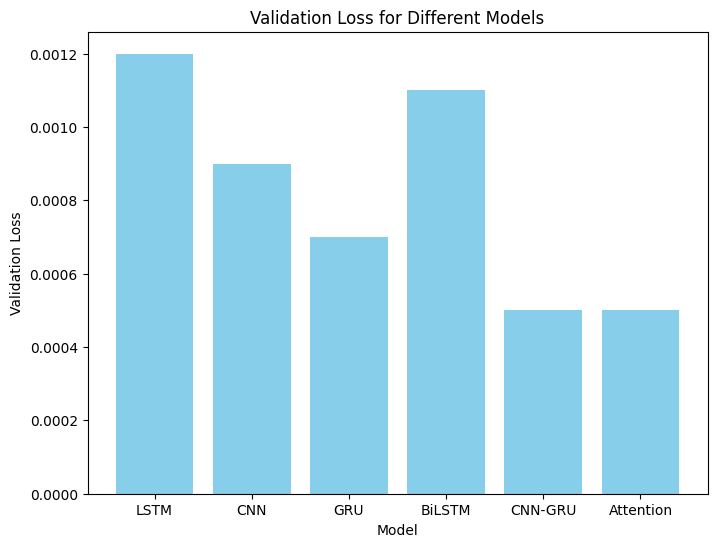

In [1]:
import matplotlib.pyplot as plt

# Data
models = ['LSTM', 'CNN', 'GRU', 'BiLSTM', 'CNN-GRU', 'Attention']
validation_loss = [0.0012, 0.0009, 0.0007, 0.0011, 0.0005, 0.0005]

# Plotting the bar graph
plt.figure(figsize=(8, 6))
plt.bar(models, validation_loss, color='skyblue')

# Adding labels and title
plt.xlabel('Model')
plt.ylabel('Validation Loss')
plt.title('Validation Loss for Different Models')

# Display the plot
plt.show()
